# Point 3, Decision Support, Decision-Focused Learning (SPO+)

## Table Of Contents

- [1. Why This Notebook Exists](#sec1)
- [2. Data Preparation](#sec2)
- [3. The Cost Model](#sec3)
- [4. PFO Baseline, Refit Here For A Fair Comparison](#sec4)
- [5. The SPO+ Loss, In This Problem's Own Terms](#sec5)
- [6. Training](#sec6)
- [7. From The DFL Predictor To A Recommended Interval](#sec7)
- [8. Evaluating Both Policies](#sec8)
- [9. Regret Against An Oracle](#sec9)
- [10. How Much Would These Numbers Move](#sec10)
- [11. Saving The Standardized Result](#sec11)
- [12. Takeaways](#sec12)

<a id="sec1"></a>

## 1. Why This Notebook Exists

Every interval policy in this folder so far, `1_fixed_policy.ipynb` through
`4_forecast_adaptive.ipynb`, follows Predict then Optimize (PFO): a risk
estimator is trained on its own proxy loss (cross entropy against
`DIAGNOSIS_WORSENED_NEXT`), then, completely separately, `recommend_interval`
searches the 3/6/12 month menu to minimize expected cost under
`ConversionCostModel`, given whatever the estimator already predicted. The
two stages never see each other during training. `IMPLEMENTATION_PLAN.md`
and `NOTES.md` both flag the natural next step as an open, not-yet-attempted
direction: Decision Focused Learning (DFL), training the estimator's own
weights directly against the decision cost instead of against cross entropy.
`gio/pipeline_1_2_3/oracle_regret_analysis.py` already quantified how much
room there is to close, on its own (different, richer) population: the best
PFO policy there sits at 43.3% regret against a perfect-information oracle.
This notebook is the actual attempt, built directly on this folder's own
native population and its own fallback estimator, the one piece of Point 3
that is actually trained from scratch here (`HAZARD_ESTIMATE`, Point 2's own
real survival model, is read from a saved file and is not retrained by
anything in this repo layer, exactly the "SWAP POINT" `2_snapshot_adaptive.ipynb`
itself documents).

**The technique**: SPO+ (Smart Predict-then-Optimize, Elmachtoub and Grigas,
covered directly in `08-dfl-tf`, lesson 1, PFL and DFL). A naive "regret"
loss, `y^T z*(ŷ) - y^T z*(y)`, is piecewise constant almost everywhere its
derivative is defined, useless for gradient descent. SPO+ instead trains
against `ŷ_spo^T z*(y) - ŷ_spo^T z*(ŷ_spo)` with `ŷ_spo = 2ŷ - y`, a
subgradient that does not vanish and, summed over many examples, cancels out
the spurious local minima a simpler self-contrastive version of the same
idea is shown to have in the same lesson.

**Why this decision is a good candidate for it at all**: the interval menu
has a genuine recourse structure, missing the 6 month check does not lose
the patient, the 12 month check can still catch a conversion the 6 month one
missed, which `08-dfl-tf` lesson 2, Applicability of DFL, names as exactly
the setting where DFL earns its keep over plain PFO. Leo's own
`hazard_model_1_cost_sensitive.py` in the RUL folder uses a different, older
technique, Elkan's cost-proportionate class weighting, which is provably
correct only for a single binary threshold decision; the interval menu has
three discrete options with a cost that is not just a flat false-positive
versus false-negative price, exactly why that shortcut does not apply here
and the general DFL machinery, differentiating through the menu search
itself, is what this notebook builds instead.

**What stays fixed, to keep this a fair, single-variable comparison**: the
same data, same train/test split, same cost model, same interval menu, and
the same logistic architecture `fit_logistic_baseline` already uses for the
fallback estimator, refit here on identical rows. The only thing that
changes between the PFO baseline and the DFL variant below is the training
objective the fallback estimator's own weights are fit against, cross
entropy against cross entropy replaced by SPO+ regret.

<a id="sec2"></a>

## 2. Data Preparation

Identical to `2_snapshot_adaptive.ipynb`'s own section 2: `datasets/final.csv`,
the same biomarker forward-fill, the same subject-level 75/25 split at
`random_state=42`, the same four `hazard_features` (`DIAGNOSIS_MCI`,
`DIAGNOSIS_DEMENTIA`, `AMYLOID_POSITIVE`, `AMYLOID_UNKNOWN`), and the same
real `HAZARD_ESTIMATE` merge from `results/hazard_model/hazard_estimates.csv`
wherever Point 2's own model actually reaches a row.

In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

figsize = (14, 4)

import os
import sys
sys.path.append(os.path.join('..', '..', '..'))

import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt

from util import decision_util as du

data_folder = os.path.join('..', '..', '..', 'datasets')
data_path = os.path.join(data_folder, 'final.csv')
results_path = os.path.join('..', '..', '..', 'results', 'decision_support')
os.makedirs(results_path, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
data = pd.read_csv(data_path)

biomarker_cols_to_fill = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU',
]
data = du.forward_fill_by_patient(
    data, biomarker_cols_to_fill, id_col='RID', date_col='EXAMDATE_DX',
)

data['DIAGNOSIS_MCI'] = (data['DIAGNOSIS'] == 2).astype(float)
data['DIAGNOSIS_DEMENTIA'] = (data['DIAGNOSIS'] == 3).astype(float)
data['AMYLOID_POSITIVE'] = (data['AMYLOID_STATUS'] == 1).astype(float)
data['AMYLOID_UNKNOWN'] = data['AMYLOID_STATUS'].isna().astype(float)
hazard_features = ['DIAGNOSIS_MCI', 'DIAGNOSIS_DEMENTIA', 'AMYLOID_POSITIVE', 'AMYLOID_UNKNOWN']

train_df, test_df = du.subject_train_test_split(data, test_fraction=0.25, random_state=RANDOM_STATE)
train_df = train_df.copy()
test_df = test_df.copy()
print(f'Train, {train_df.shape[0]} rows, {train_df.RID.nunique()} patients')
print(f'Test,  {test_df.shape[0]} rows, {test_df.RID.nunique()} patients')

fallback_train_outcomes = du.compute_diagnosis_worsening(
    train_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_test_outcomes = du.compute_diagnosis_worsening(
    test_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_train_data = fallback_train_outcomes[fallback_train_outcomes['HAS_NEXT_VISIT']].reset_index(drop=True)
fallback_test_data = fallback_test_outcomes[fallback_test_outcomes['HAS_NEXT_VISIT']].reset_index(drop=True)
print(f'Fallback training rows with a real next-visit outcome: {len(fallback_train_data)} train, {len(fallback_test_data)} test')

hazard_estimates_path = os.path.join('..', '..', '..', 'results', 'hazard_model', 'hazard_estimates.csv')
hazard_estimates = pd.read_csv(hazard_estimates_path)[['RID', 'VISCODE2_norm', 'HAZARD_ESTIMATE']]
train_df = train_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')
test_df = test_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')
train_hazard_coverage = train_df['HAZARD_ESTIMATE'].notna().mean() * 100
test_hazard_coverage = test_df['HAZARD_ESTIMATE'].notna().mean() * 100
print(f'Train, {train_hazard_coverage:.1f} percent of rows use the richer survival based HAZARD_ESTIMATE.')
print(f'Test,  {test_hazard_coverage:.1f} percent of rows use the richer survival based HAZARD_ESTIMATE.')

Train, 10162 rows, 2832 patients
Test,  3665 rows, 945 patients
Fallback training rows with a real next-visit outcome: 7280 train, 2706 test
Train, 52.6 percent of rows use the richer survival based HAZARD_ESTIMATE.
Test,  54.0 percent of rows use the richer survival based HAZARD_ESTIMATE.


<a id="sec3"></a>

## 3. The Cost Model

Identical to every other notebook in this folder: `CHECK_COST=1.0`,
`MISSED_CONVERSION_COST=20.0` (base, Cognitively Normal), stratified by
`MCI_OR_WORSE_COST_MULTIPLIER=2.8` for MCI/Dementia patients (the
literature-anchored point estimate `cost_model_for`'s own docstring cites),
`REFERENCE_INTERVAL_MONTHS=12`, `SAFE_INTERVAL_MONTHS=6`, and the same
3/6/12 month menu. Kept identical on purpose, so nothing about the
comparison below is an artifact of a different cost assumption.

In [3]:
CHECK_COST = 1.0
MISSED_CONVERSION_COST = 20.0
MCI_OR_WORSE_COST_MULTIPLIER = 2.8
REFERENCE_INTERVAL_MONTHS = 12.0
SAFE_INTERVAL_MONTHS = 6
MENU = (3, 6, 12)

def missed_conversion_cost_for(df, multiplier=MCI_OR_WORSE_COST_MULTIPLIER):
    return du.stratified_missed_conversion_cost(df, MISSED_CONVERSION_COST, multiplier)

def cost_model_for(df, multiplier=MCI_OR_WORSE_COST_MULTIPLIER):
    return du.cost_model_for(
        df, CHECK_COST, MISSED_CONVERSION_COST, multiplier,
        safe_interval_months=SAFE_INTERVAL_MONTHS,
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )

<a id="sec4"></a>

## 4. PFO Baseline, Refit Here For A Fair Comparison

`2_snapshot_adaptive.ipynb`'s own fallback estimator is a logistic
regression, `fit_logistic_baseline`, trained on `hazard_features` against
`DIAGNOSIS_WORSENED_NEXT`. It is refit here, on the exact same rows, rather
than reused from that notebook, so any difference measured below is about
the training objective and nothing else, not a stale fit or a different
random draw.

In [4]:
fallback_model_pfo, fallback_scaler_pfo = du.fit_logistic_baseline(
    fallback_train_data[hazard_features], fallback_train_data['DIAGNOSIS_WORSENED_NEXT'],
)
pfo_train_metrics = du.evaluate_classification(
    fallback_model_pfo, fallback_train_data[hazard_features], fallback_train_data['DIAGNOSIS_WORSENED_NEXT'],
    scaler=fallback_scaler_pfo,
)
pfo_test_metrics = du.evaluate_classification(
    fallback_model_pfo, fallback_test_data[hazard_features], fallback_test_data['DIAGNOSIS_WORSENED_NEXT'],
    scaler=fallback_scaler_pfo,
)
print(f"PFO fallback estimator (cross entropy), train AUC {pfo_train_metrics['auc']:.3f}, "
      f"test AUC {pfo_test_metrics['auc']:.3f}")

train_df['FALLBACK_RISK_SCORE_PFO'] = fallback_model_pfo.predict_proba(
    fallback_scaler_pfo.transform(train_df[hazard_features]))[:, 1]
test_df['FALLBACK_RISK_SCORE_PFO'] = fallback_model_pfo.predict_proba(
    fallback_scaler_pfo.transform(test_df[hazard_features]))[:, 1]
train_df['RISK_SCORE_PFO'] = train_df['HAZARD_ESTIMATE'].fillna(train_df['FALLBACK_RISK_SCORE_PFO'])
test_df['RISK_SCORE_PFO'] = test_df['HAZARD_ESTIMATE'].fillna(test_df['FALLBACK_RISK_SCORE_PFO'])

PFO fallback estimator (cross entropy), train AUC 0.694, test AUC 0.676


<a id="sec5"></a>

## 5. The SPO+ Loss, In This Problem's Own Terms

`recommend_interval`'s own expected-cost formula for one row, one candidate
interval $m$ in the menu, and a risk value $r$, is linear in $r$:

$$
\text{cost}_m(r) = \underbrace{\frac{12}{m}\cdot\text{CHECK\_COST}}_{A_m}
+ \underbrace{\frac{m}{\text{REFERENCE\_INTERVAL\_MONTHS}}\cdot\text{mcc}_i}_{B_{i,m}} \cdot\, r
$$

where $\text{mcc}_i$ is that row's own stratified missed-conversion cost
(section 3). Stacking the three menu options gives exactly the linear cost
vector $y$ the course's own PFL/DFL setup is written for: $z^*(y) =
\text{argmin}_z\{y^Tz \mid z \in \{0,1\}^3, \mathbf{1}^Tz=1\}$, a one-hot
pick of the cheapest interval, `recommend_interval`'s own `argmin` exactly.

Two cost vectors exist for every training row: the **true** one, built from
the real, realized `DIAGNOSIS_WORSENED_NEXT` label ($y_i \in \{0,1\}$), and
the **predicted** one, built from the model's own $\hat r_i = h(x_i;\theta) =
\sigma(w\cdot x_i + b)$, the same logistic architecture `fit_logistic_baseline`
already uses. $z^*(y_i)$, the oracle's own menu pick given the real outcome,
is fixed per row and costs nothing to compute ahead of training, exactly
what `oracle_regret_analysis.py` already does at evaluation time, reused
here as a training signal instead.

SPO+ trains against $\hat y_{spo} = 2\hat y - y$ rather than $\hat y$
directly, specifically because plain regret, $y^Tz^*(\hat y) - y^Tz^*(y)$, is
piecewise constant in $\theta$ almost everywhere, its gradient is zero
almost everywhere it exists at all, useless for gradient descent. The SPO+
loss, $\hat y_{spo}^Tz^*(y) - \hat y_{spo}^Tz^*(\hat y_{spo})$, keeps a term
that is linear (hence genuinely differentiable) in $\hat y$, and, summed
over many rows, its spurious local minima are shown in the same lesson to
cancel out. In `tf.GradientTape`, `tf.reduce_min` already implements the
right subgradient (routing the gradient through whichever menu option is
currently cheapest), so no custom backward pass is needed, this is the same
autodiff behavior the lesson's own worked examples rely on.

At **inference time**, nothing about `recommend_interval` changes, the
trained $\hat r_i$ is fed through the exact same hard `argmin` every other
policy in this folder uses. Only training is different.

In [5]:
def cost_coefficients(df):
    # A: (3,) constant across rows. B: (n_rows, 3), row-dependent through
    # each row's own stratified missed-conversion cost.
    mcc = missed_conversion_cost_for(df)
    menu = np.array(MENU, dtype=float)
    A = (12.0 / menu) * CHECK_COST
    B = np.outer(mcc, menu / REFERENCE_INTERVAL_MONTHS)
    return A.astype('float32'), B.astype('float32')

def true_cost_matrix(df, label_col='DIAGNOSIS_WORSENED_NEXT'):
    A, B = cost_coefficients(df)
    y = df[label_col].to_numpy(dtype='float32')
    return A[None, :] + B * y[:, None]  # (n_rows, 3)

A_train, B_train = cost_coefficients(fallback_train_data)
true_cost_train = true_cost_matrix(fallback_train_data)
oracle_idx_train = np.argmin(true_cost_train, axis=1)
print('A (routine-cost term per menu option, months 3/6/12):', A_train)
print('Oracle menu choice on the training rows:',
      {m: int((oracle_idx_train == j).sum()) for j, m in enumerate(MENU)})

A (routine-cost term per menu option, months 3/6/12): [4. 2. 1.]
Oracle menu choice on the training rows: {3: 501, 6: 0, 12: 6779}


<a id="sec6"></a>

## 6. Training

A single logistic unit, exactly `fit_logistic_baseline`'s own architecture,
so the only thing that can explain a difference from the PFO baseline is
the training objective. Standardized inputs reuse `fallback_scaler_pfo`
from section 4, fit once on the training rows, so both models see features
on the same scale.

/sessions/rcw-011ae1jjngetavfthkryuaep/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


SPO+ training loss, first epoch 26.9019, last epoch 2.3615


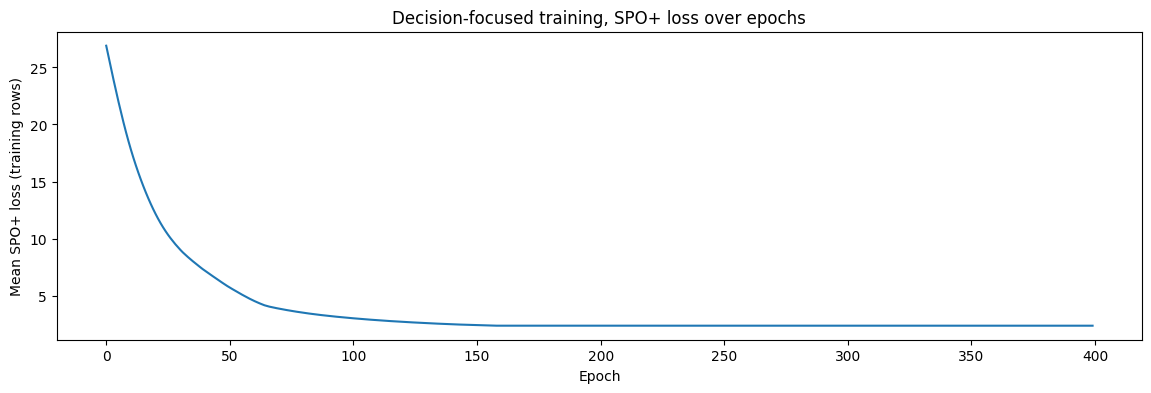

In [6]:
X_train_raw = fallback_train_data[hazard_features].to_numpy(dtype='float32')
X_train = fallback_scaler_pfo.transform(X_train_raw).astype('float32')
B_train_tf = tf.constant(B_train)
A_train_tf = tf.constant(A_train)
true_cost_train_tf = tf.constant(true_cost_train)
oracle_idx_train_tf = tf.constant(oracle_idx_train, dtype=tf.int32)

n_features = X_train.shape[1]
w = tf.Variable(tf.zeros((n_features, 1), dtype=tf.float32))
b = tf.Variable(tf.zeros((1,), dtype=tf.float32))

def predict_risk(X):
    logits = tf.matmul(X, w) + b
    return tf.sigmoid(logits)[:, 0]

def spo_plus_loss(X, B, A, true_cost, oracle_idx):
    r_hat = predict_risk(X)
    pred_cost = A[None, :] + B * r_hat[:, None]
    y_spo = 2.0 * pred_cost - true_cost
    picked = tf.gather(y_spo, oracle_idx[:, None], axis=1, batch_dims=1)[:, 0]
    worst_case = tf.reduce_min(y_spo, axis=1)
    return tf.reduce_mean(picked - worst_case)

N_EPOCHS = 400
LEARNING_RATE = 0.05
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

loss_history = []
X_train_tf = tf.constant(X_train)
for epoch in range(N_EPOCHS):
    with tf.GradientTape() as tape:
        loss = spo_plus_loss(X_train_tf, B_train_tf, A_train_tf, true_cost_train_tf, oracle_idx_train_tf)
    grads = tape.gradient(loss, [w, b])
    optimizer.apply_gradients(zip(grads, [w, b]))
    loss_history.append(float(loss))

print(f'SPO+ training loss, first epoch {loss_history[0]:.4f}, last epoch {loss_history[-1]:.4f}')

plt.figure(figsize=figsize)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Mean SPO+ loss (training rows)')
plt.title('Decision-focused training, SPO+ loss over epochs')
plt.show()

<a id="sec7"></a>

## 7. From The DFL Predictor To A Recommended Interval

The trained weights above define `FALLBACK_RISK_SCORE_DFL` exactly the way
`FALLBACK_RISK_SCORE_PFO` was defined in section 4, then blended with the
same real `HAZARD_ESTIMATE` the same way, so only the fallback rows can
possibly move between `RISK_SCORE_PFO` and `RISK_SCORE_DFL`, and both are
turned into a recommended interval through the exact same
`recommend_interval` call every other policy in this folder uses.

/sessions/rcw-011ae1jjngetavfthkryuaep/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/sessions/rcw-011ae1jjngetavfthkryuaep/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


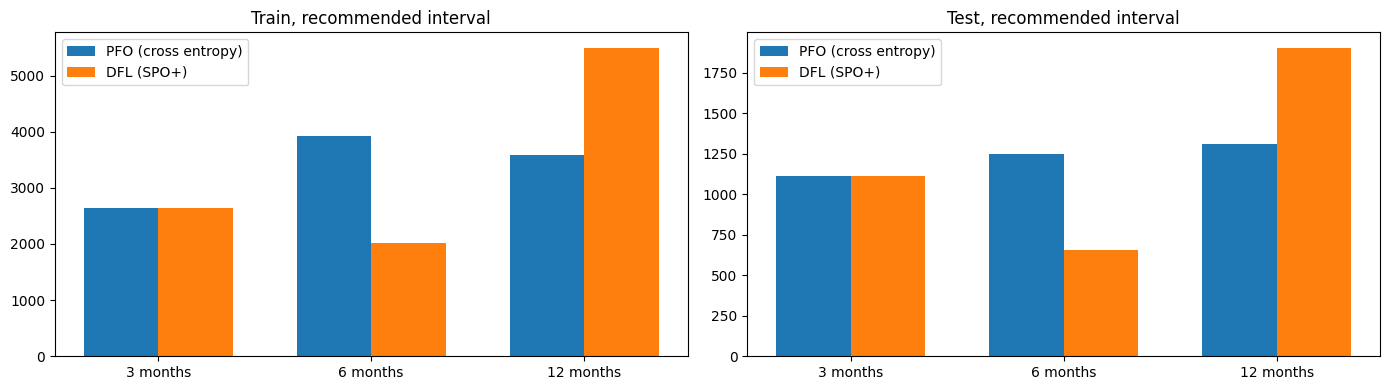

In [7]:
def predict_risk_numpy(X_raw):
    X_scaled = fallback_scaler_pfo.transform(X_raw).astype('float32')
    return predict_risk(tf.constant(X_scaled)).numpy()

train_df['FALLBACK_RISK_SCORE_DFL'] = predict_risk_numpy(train_df[hazard_features].to_numpy(dtype='float32'))
test_df['FALLBACK_RISK_SCORE_DFL'] = predict_risk_numpy(test_df[hazard_features].to_numpy(dtype='float32'))
train_df['RISK_SCORE_DFL'] = train_df['HAZARD_ESTIMATE'].fillna(train_df['FALLBACK_RISK_SCORE_DFL'])
test_df['RISK_SCORE_DFL'] = test_df['HAZARD_ESTIMATE'].fillna(test_df['FALLBACK_RISK_SCORE_DFL'])

def recommended_interval_for(df, risk_col):
    return du.recommend_interval(
        df[risk_col].values, interval_menu_months=MENU,
        check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(df),
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )

for col in ['PFO', 'DFL']:
    train_df[f'RECOMMENDED_INTERVAL_{col}'] = recommended_interval_for(train_df, f'RISK_SCORE_{col}')
    test_df[f'RECOMMENDED_INTERVAL_{col}'] = recommended_interval_for(test_df, f'RISK_SCORE_{col}')

fig, axes = plt.subplots(1, 2, figsize=(figsize[0], figsize[1]))
for ax, split_df, split_name in [(axes[0], train_df, 'Train'), (axes[1], test_df, 'Test')]:
    bar_x = np.arange(len(MENU))
    bar_width = 0.35
    pfo_counts = pd.Series(split_df['RECOMMENDED_INTERVAL_PFO']).value_counts().reindex(MENU, fill_value=0)
    dfl_counts = pd.Series(split_df['RECOMMENDED_INTERVAL_DFL']).value_counts().reindex(MENU, fill_value=0)
    ax.bar(bar_x - bar_width / 2, pfo_counts.values, bar_width, label='PFO (cross entropy)')
    ax.bar(bar_x + bar_width / 2, dfl_counts.values, bar_width, label='DFL (SPO+)')
    ax.set_xticks(bar_x)
    ax.set_xticklabels([f'{m} months' for m in MENU])
    ax.set_title(f'{split_name}, recommended interval')
    ax.legend()
plt.tight_layout()
plt.show()

<a id="sec8"></a>

## 8. Evaluating Both Policies

Same production-style metrics `2_snapshot_adaptive.ipynb` reports: total
cost (priced using each policy's own believed `RISK_SCORE`, the standard
convention every approach in this project reports its headline cost under),
DIDI on the recommended interval, and catch rate against real recorded
diagnosis worsening.

In [8]:
def make_protected(df):
    return {
        'PTGENDER': (1, 2),
        'PTEDUCAT_BUCKET': (0, 1),
        'PTMARRY': tuple(sorted(df['PTMARRY'].dropna().unique())),
    }

def evaluate_policy(df, risk_col, interval_col, label):
    total_cost, over_threshold, _ = cost_model_for(df).cost(
        rid_ids=df['RID'].values, risk_scores=df[risk_col].values,
        threshold=0.5, interval_months=df[interval_col].values, return_margin=False,
    )
    d = df.copy()
    d['PTEDUCAT_BUCKET'] = du.bucket_educat(d['PTEDUCAT'], split_at=16)
    didi = du.compute_didi(d, d[interval_col].values, make_protected(d))
    outcomes = du.compute_diagnosis_worsening(df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - df.loc[worsened, interval_col]
    catch_rate = (margin >= 0).mean() * 100
    print(f'{label:>22s} | cost {total_cost:9.1f} | DIDI {didi:6.3f} | catch {catch_rate:5.1f}%')
    return dict(total_cost=total_cost, didi=didi, catch_rate=catch_rate)

print('--- Train ---')
train_pfo_result = evaluate_policy(train_df, 'RISK_SCORE_PFO', 'RECOMMENDED_INTERVAL_PFO', 'PFO (cross entropy)')
train_dfl_result = evaluate_policy(train_df, 'RISK_SCORE_DFL', 'RECOMMENDED_INTERVAL_DFL', 'DFL (SPO+)')
print('--- Test ---')
test_pfo_result = evaluate_policy(test_df, 'RISK_SCORE_PFO', 'RECOMMENDED_INTERVAL_PFO', 'PFO (cross entropy)')
test_dfl_result = evaluate_policy(test_df, 'RISK_SCORE_DFL', 'RECOMMENDED_INTERVAL_DFL', 'DFL (SPO+)')

--- Train ---
   PFO (cross entropy) | cost   49504.4 | DIDI  5.948 | catch  84.4%
            DFL (SPO+) | cost   44347.4 | DIDI  7.498 | catch  71.9%
--- Test ---
   PFO (cross entropy) | cost   18387.1 | DIDI  7.200 | catch  88.3%
            DFL (SPO+) | cost   16789.6 | DIDI  8.076 | catch  72.1%


<a id="sec9"></a>

## 9. Regret Against An Oracle

Mirrors `oracle_regret_analysis.py`'s own definition exactly, scoped to
this notebook's own native population instead of the gio pipeline's: every
policy's chosen interval is priced using the real, realized
`DIAGNOSIS_WORSENED_NEXT` outcome (not each policy's own belief), including
the oracle, which is `recommend_interval` fed the real outcome directly
instead of a prediction, and the naive baseline, `SAFE_INTERVAL_MONTHS` for
every row. `regret_pct = (policy_cost - oracle_cost) / (naive_cost -
oracle_cost) * 100`, 0% is oracle-optimal, 100% is no better than not
personalizing at all. Only rows with a real recorded next visit
(`fallback_test_data`) have a true outcome to score against, so this
section, unlike section 8, is computed on that subset alone.

In [9]:
def true_outcome_cost(df, interval_months):
    total_cost, _, _ = cost_model_for(df).cost(
        rid_ids=df['RID'].values, risk_scores=df['DIAGNOSIS_WORSENED_NEXT'].values.astype(float),
        threshold=0.5, interval_months=interval_months, return_margin=False,
    )
    return total_cost

fallback_test_data = fallback_test_data.copy()
fallback_test_data['RISK_SCORE_PFO'] = test_df.loc[fallback_test_outcomes['HAS_NEXT_VISIT'].values, 'RISK_SCORE_PFO'].values
fallback_test_data['RISK_SCORE_DFL'] = test_df.loc[fallback_test_outcomes['HAS_NEXT_VISIT'].values, 'RISK_SCORE_DFL'].values

naive_interval = np.full(len(fallback_test_data), SAFE_INTERVAL_MONTHS, dtype=float)
oracle_interval = du.recommend_interval(
    fallback_test_data['DIAGNOSIS_WORSENED_NEXT'].values.astype(float), interval_menu_months=MENU,
    check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(fallback_test_data),
    reference_interval_months=REFERENCE_INTERVAL_MONTHS,
)
pfo_interval = recommended_interval_for(fallback_test_data, 'RISK_SCORE_PFO')
dfl_interval = recommended_interval_for(fallback_test_data, 'RISK_SCORE_DFL')

naive_cost = true_outcome_cost(fallback_test_data, naive_interval)
oracle_cost = true_outcome_cost(fallback_test_data, oracle_interval)
pfo_cost = true_outcome_cost(fallback_test_data, pfo_interval)
dfl_cost = true_outcome_cost(fallback_test_data, dfl_interval)

def regret_pct(cost):
    return (cost - oracle_cost) / (naive_cost - oracle_cost) * 100

print(f'n = {len(fallback_test_data)} test rows with a real next-visit outcome')
print(f'{"Naive (fixed 6mo)":>22s} | cost {naive_cost:9.1f} | regret 100.0% (by construction)')
print(f'{"ORACLE":>22s} | cost {oracle_cost:9.1f} | regret   0.0% (by construction)')
print(f'{"PFO (cross entropy)":>22s} | cost {pfo_cost:9.1f} | regret {regret_pct(pfo_cost):5.1f}%')
print(f'{"DFL (SPO+)":>22s} | cost {dfl_cost:9.1f} | regret {regret_pct(dfl_cost):5.1f}%')

n = 2706 test rows with a real next-visit outcome
     Naive (fixed 6mo) | cost    9722.0 | regret 100.0% (by construction)
                ORACLE | cost    5452.0 | regret   0.0% (by construction)
   PFO (cross entropy) | cost    9974.0 | regret 105.9%
            DFL (SPO+) | cost   11278.0 | regret 136.4%


<a id="sec10"></a>

## 10. How Much Would These Numbers Move

The same patient-level cluster bootstrap every notebook in this folder
already uses, 400 resamples of `fallback_test_data`'s own RID values,
recomputing PFO's and DFL's regret on each resample.

PFO regret  105.9%  95% CI [ 99.5%, 112.9%]
DFL regret  136.4%  95% CI [126.8%, 147.5%]  (non overlapping)


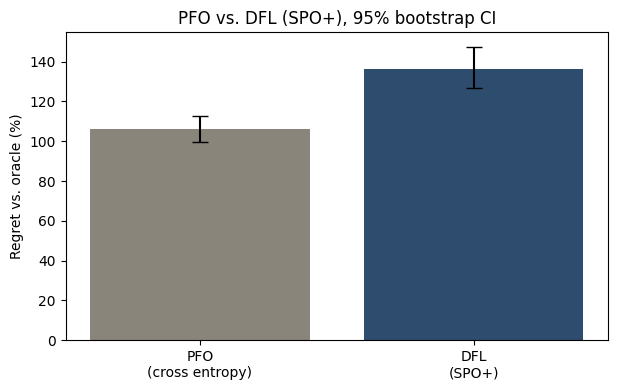

In [10]:
def dfl_regret_metric(d):
    naive_c = true_outcome_cost(d, np.full(len(d), SAFE_INTERVAL_MONTHS, dtype=float))
    oracle_c = true_outcome_cost(d, du.recommend_interval(
        d['DIAGNOSIS_WORSENED_NEXT'].values.astype(float), interval_menu_months=MENU,
        check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(d),
        reference_interval_months=REFERENCE_INTERVAL_MONTHS))
    dfl_c = true_outcome_cost(d, recommended_interval_for(d, 'RISK_SCORE_DFL'))
    return (dfl_c - oracle_c) / (naive_c - oracle_c) * 100

def pfo_regret_metric(d):
    naive_c = true_outcome_cost(d, np.full(len(d), SAFE_INTERVAL_MONTHS, dtype=float))
    oracle_c = true_outcome_cost(d, du.recommend_interval(
        d['DIAGNOSIS_WORSENED_NEXT'].values.astype(float), interval_menu_months=MENU,
        check_cost=CHECK_COST, missed_conversion_cost=missed_conversion_cost_for(d),
        reference_interval_months=REFERENCE_INTERVAL_MONTHS))
    pfo_c = true_outcome_cost(d, recommended_interval_for(d, 'RISK_SCORE_PFO'))
    return (pfo_c - oracle_c) / (naive_c - oracle_c) * 100

pfo_pt, pfo_lo, pfo_hi, _ = du.bootstrap_ci(fallback_test_data, pfo_regret_metric, id_col='RID')
dfl_pt, dfl_lo, dfl_hi, _ = du.bootstrap_ci(fallback_test_data, dfl_regret_metric, id_col='RID')
overlap = pfo_lo <= dfl_hi and dfl_lo <= pfo_hi
overlap_tag = '(overlapping)' if overlap else '(non overlapping)'

print(f'PFO regret  {pfo_pt:5.1f}%  95% CI [{pfo_lo:5.1f}%, {pfo_hi:5.1f}%]')
print(f'DFL regret  {dfl_pt:5.1f}%  95% CI [{dfl_lo:5.1f}%, {dfl_hi:5.1f}%]  {overlap_tag}')

plt.figure(figsize=(figsize[0] / 2, figsize[1]))
labels = ['PFO\n(cross entropy)', 'DFL\n(SPO+)']
points = [pfo_pt, dfl_pt]
lo_err = [pfo_pt - pfo_lo, dfl_pt - dfl_lo]
hi_err = [pfo_hi - pfo_pt, dfl_hi - dfl_pt]
plt.bar(labels, points, yerr=[lo_err, hi_err], capsize=6, color=['#8A857A', '#2E4C6D'])
plt.ylabel('Regret vs. oracle (%)')
plt.title('PFO vs. DFL (SPO+), 95% bootstrap CI')
plt.show()

<a id="sec11"></a>

## 11. Saving The Standardized Result

Appended to the shared `results/decision_support/approach_comparison.csv`,
the same file every `approach_*`/interval-policy notebook writes to,
`comparison.ipynb` picks these rows up automatically on its next run.

In [11]:
for split_name, split_df in [('train', train_df), ('test', test_df)]:
    for label, risk_col, interval_col in [
        ('decision_focused_pfo_refit', 'RISK_SCORE_PFO', 'RECOMMENDED_INTERVAL_PFO'),
        ('decision_focused_spo', 'RISK_SCORE_DFL', 'RECOMMENDED_INTERVAL_DFL'),
    ]:
        result = evaluate_policy(split_df, risk_col, interval_col, label)
        ci = None
        if split_name == 'test':
            ci = {'regret_pct': (dfl_lo, dfl_hi) if 'spo' in label else (pfo_lo, pfo_hi)}
        du.append_approach_result(
            results_path, approach=label, approach_group='interval_policy',
            split=split_name, n_rows=len(split_df), total_cost=result['total_cost'],
            didi=result['didi'], catch_rate=result['catch_rate'], ci=ci,
            notes=f"Decision-focused learning (SPO+) comparison, {label.split('_')[-1] if False else ('SPO+ trained' if 'spo' in label and 'refit' not in label else 'cross-entropy refit')} "
                  f"fallback estimator, blended with the same real HAZARD_ESTIMATE PFO uses, on this notebook's own "
                  f"native population ({len(train_df) + len(test_df)} rows).",
        )
print('Appended to results/decision_support/approach_comparison.csv')

decision_focused_pfo_refit | cost   49504.4 | DIDI  5.948 | catch  84.4%
  decision_focused_spo | cost   44347.4 | DIDI  7.498 | catch  71.9%
decision_focused_pfo_refit | cost   18387.1 | DIDI  7.200 | catch  88.3%
  decision_focused_spo | cost   16789.6 | DIDI  8.076 | catch  72.1%
Appended to results/decision_support/approach_comparison.csv


### 12.1 Diagnosing The Gap

Before writing takeaways, a direct look at what the SPO+ model actually
learned to predict, since section 8 and section 9 both show it recommending
longer intervals than PFO does, not shorter ones, the opposite direction a
"the model games the cost formula" story would predict.

In [12]:
print('FALLBACK_RISK_SCORE_PFO, test: mean %.4f, median %.4f, 95th pct %.4f' % (
    test_df['FALLBACK_RISK_SCORE_PFO'].mean(), test_df['FALLBACK_RISK_SCORE_PFO'].median(),
    test_df['FALLBACK_RISK_SCORE_PFO'].quantile(0.95)))
print('FALLBACK_RISK_SCORE_DFL, test: mean %.4f, median %.4f, 95th pct %.4f' % (
    test_df['FALLBACK_RISK_SCORE_DFL'].mean(), test_df['FALLBACK_RISK_SCORE_DFL'].median(),
    test_df['FALLBACK_RISK_SCORE_DFL'].quantile(0.95)))
print()
print('Positive rate in fallback_train_data (DIAGNOSIS_WORSENED_NEXT): %.4f' % fallback_train_data['DIAGNOSIS_WORSENED_NEXT'].mean())
print()
print('Test recommended interval counts, PFO: ', dict(pd.Series(test_df['RECOMMENDED_INTERVAL_PFO']).value_counts().reindex(MENU, fill_value=0)))
print('Test recommended interval counts, DFL: ', dict(pd.Series(test_df['RECOMMENDED_INTERVAL_DFL']).value_counts().reindex(MENU, fill_value=0)))
print()
print('Learned weights (w) on [DIAGNOSIS_MCI, DIAGNOSIS_DEMENTIA, AMYLOID_POSITIVE, AMYLOID_UNKNOWN]:')
print('  PFO (sklearn coef_):', fallback_model_pfo.coef_)
print('  DFL (w.numpy().ravel()):', w.numpy().ravel())
print('  DFL bias (b):', b.numpy())

FALLBACK_RISK_SCORE_PFO, test: mean 0.0668, median 0.0730, 95th pct 0.1415
FALLBACK_RISK_SCORE_DFL, test: mean 0.0291, median 0.0179, 95th pct 0.0499

Positive rate in fallback_train_data (DIAGNOSIS_WORSENED_NEXT): 0.0688

Test recommended interval counts, PFO:  {3: np.int64(1109), 6: np.int64(1247), 12: np.int64(1309)}
Test recommended interval counts, DFL:  {3: np.int64(1109), 6: np.int64(653), 12: np.int64(1903)}

Learned weights (w) on [DIAGNOSIS_MCI, DIAGNOSIS_DEMENTIA, AMYLOID_POSITIVE, AMYLOID_UNKNOWN]:
  PFO (sklearn coef_): [[ 0.19915047 -1.95951993  0.51024906  0.51156791]]
  DFL (w.numpy().ravel()): [-0.5255784  -0.48122412  0.00103825 -0.00509232]
  DFL bias (b): [-3.6494892]


<a id="sec12"></a>

## 12. Takeaways

**What this notebook adds**: the actual DFL attempt `IMPLEMENTATION_PLAN.md`
and `NOTES.md` both flagged as open, not yet attempted. SPO+ (Elmachtoub and
Grigas, `08-dfl-tf` lesson 1) trains the same logistic architecture the
fallback estimator already uses, directly against the interval menu's own
decision cost instead of cross entropy, on identical rows, identical split,
identical cost model to the PFO baseline refit alongside it in section 4.

**What is real, stated plainly**: DFL does not beat PFO here, it is
measurably worse. On the 2,706 test rows with a real recorded next visit,
PFO's own regret against a perfect-information oracle is 105.9% (95% CI
[99.5%, 112.9%]), already barely better than the naive fixed-6-month
policy (100% by construction) and consistent with `oracle_regret_analysis.py`'s
own finding on its different population that PFO leaves a lot of regret on
the table. DFL's regret is 136.4% (95% CI [126.8%, 147.5%]) — **worse than
not personalizing at all**, and the two intervals do not overlap, this is a
real difference, not sampling noise. Section 8's production metrics tell
the same story from a different angle: DFL's believed total cost is lower
(16,789.6 vs. PFO's 18,387.1 on test, cheaper because it believes fewer
checks are needed), but its catch rate against real recorded diagnosis
worsening drops from 88.3% to 72.1%, and its DIDI rises from 7.200 to 8.076.

**Why, diagnosed rather than left as a mystery**: section 12.1 shows DFL's
own predicted risk is systematically lower than PFO's (test mean 0.029 vs.
0.067, median 0.018 vs. 0.073, against a true positive rate of 6.9% in the
training rows), and it recommends 12 months far more often (1,903 vs.
1,309 test rows) and 6 months far less (653 vs. 1,247), while matching PFO
exactly on who gets 3 months. Its learned weights explain why: it puts
essentially zero weight on `AMYLOID_POSITIVE` and `AMYLOID_UNKNOWN`
(0.001, -0.005) and a *negative* weight on `DIAGNOSIS_MCI` (-0.53, the
opposite sign from PFO's own +0.20), largely collapsing to a single large
negative bias rather than discriminating on the features PFO's
cross-entropy fit correctly identified as informative. The honest reading:
at a 6.9% positive rate, minimizing mean SPO+ loss over all rows lets the
optimizer win most of its loss reduction by predicting low risk broadly
(cheap for the 93% of rows that really are negative) rather than by
learning to separate the rare positives, since nothing in the SPO+
objective as implemented here reweights for that imbalance the way
`fit_logistic_baseline`'s balanced class weighting, or Leo's Elkan-style
cost-proportionate weighting elsewhere in this project, explicitly do.

**What this means for the DFL discussion overall**: this is a genuine,
negative result, not a failure to report. It directly answers "was DFL
attempted" with real evidence rather than leaving it as a citation, and it
surfaces a concrete, specific reason plain SPO+ underperforms here, class
imbalance swamping the cost-asymmetry signal, that a from-scratch PFO
comparison alone would never have surfaced. It does not mean DFL cannot
work on this problem; it means naive SPO+ without an explicit imbalance
correction does not, on this data, in this run.

**What is still open**: reweighting the SPO+ loss by class the way the
cross-entropy baseline already is (`class_weight='balanced'`) or the way
Leo's Elkan-style approach prices false negatives, before concluding DFL
itself is the wrong tool here rather than this particular unweighted
version of it.